In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

df = sns.load_dataset('titanic')

print(df.head())
print("-" * 30)
print(df.info())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  ----- 

In [2]:
# 1. Удаление дубликатов и лишних признаков
df = df.drop_duplicates()
# Удаляем 'deck' (слишком много пропусков), 'embark_town' (дублирует embarked),
# 'alive' (дублирует target), 'who' и 'adult_male' (дублируют sex/age), 'class' (дублирует pclass)
cols_to_drop = ['deck', 'embark_town', 'alive', 'who', 'adult_male', 'class']
df = df.drop(columns=cols_to_drop)

# 2. Обработка пропусков
# Заполняем возраст медианой, а порт посадки (embarked) модой (самым частым значением)
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# 3. Кодирование категориальных признаков (Sex, Embarked)
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex']) # male/female -> 0/1
df['embarked'] = le.fit_transform(df['embarked']) # S/C/Q -> 0/1/2
# boolean поля тоже приводим к int
df['alone'] = df['alone'].astype(int)

# 4. Выделение X (признаки) и y (целевая переменная)
X = df.drop('survived', axis=1)
y = df['survived']

# 5. Стандартизация (важно для Логистической регрессии и KNN)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Размер данных после обработки:", X_scaled.shape)
print(X_scaled.head())

Размер данных после обработки: (784, 8)
     pclass       sex       age     sibsp     parch      fare  embarked  \
0  0.885158  0.772490 -0.557360  0.484009 -0.497157 -0.526825  0.586250   
1 -1.455362 -1.294515  0.608298  0.484009 -0.497157  0.701587 -1.904915   
2  0.885158 -1.294515 -0.265945 -0.530599 -0.497157 -0.513876  0.586250   
3 -1.455362 -1.294515  0.389737  0.484009 -0.497157  0.352760  0.586250   
4  0.885158  0.772490  0.389737 -0.530599 -0.497157 -0.511478  0.586250   

      alone  
0 -1.148707  
1 -1.148707  
2  0.870544  
3 -1.148707  
4  0.870544  


In [ ]:
# Разделяем данные: 80% на обучение, 20% на тест
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Вспомогательная функция для оценки
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    print(f"--- {model_name} ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
    if y_proba is not None:
        print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

    # Матрица ошибок
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()
    print("\n")

--- LogReg Default ---
Accuracy: 0.7707
Precision: 0.7797
Recall: 0.6667
F1-Score: 0.7188
ROC-AUC: 0.8442


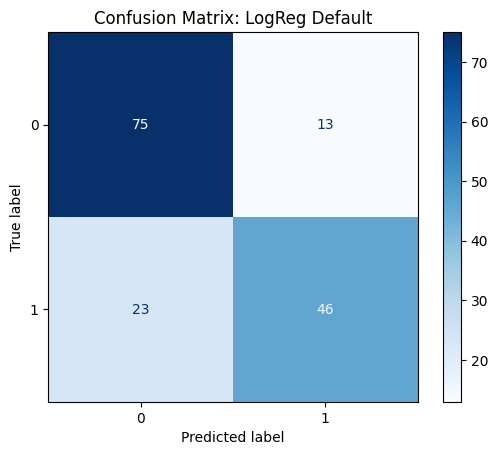



Лучшие параметры LogReg: {'C': 0.1, 'penalty': 'l2'}
--- LogReg Tuned ---
Accuracy: 0.7707
Precision: 0.7705
Recall: 0.6812
F1-Score: 0.7231
ROC-AUC: 0.8463


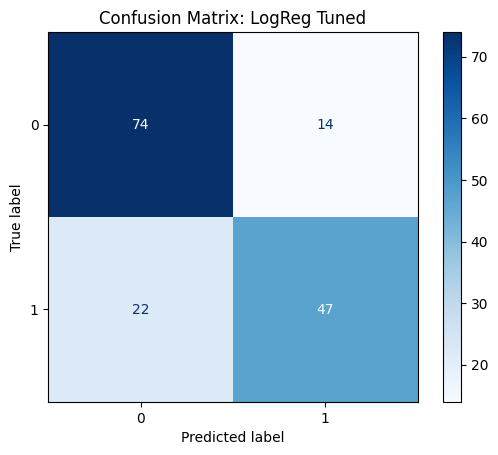

In [5]:
# 1. Модель с параметрами по умолчанию
log_reg_default = LogisticRegression(random_state=42)
log_reg_default.fit(X_train, y_train)
evaluate_model(log_reg_default, X_test, y_test, "LogReg Default")

# 2. Подбор гиперпараметров (GridSearchCV)
params_lr = {
    'C': [0.01, 0.1, 1, 10, 100],  # Сила регуляризации
    'penalty': ['l2'] # Тип регуляризации
}

log_reg_grid = GridSearchCV(LogisticRegression(random_state=42), params_lr, cv=5, scoring='f1')
log_reg_grid.fit(X_train, y_train)

print("Лучшие параметры LogReg:", log_reg_grid.best_params_)
evaluate_model(log_reg_grid.best_estimator_, X_test, y_test, "LogReg Tuned")

--- KNN Default ---
Accuracy: 0.7580
Precision: 0.7313
Recall: 0.7101
F1-Score: 0.7206
ROC-AUC: 0.8100


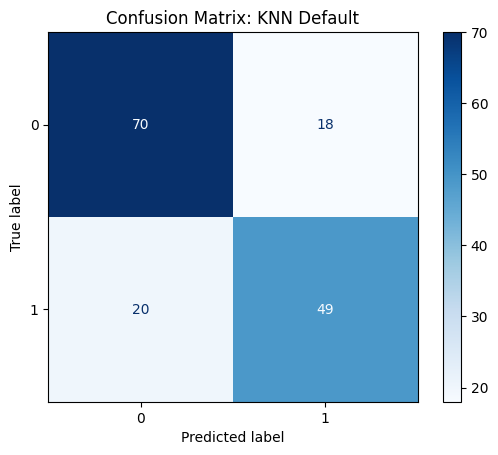



Лучшие параметры KNN: {'n_neighbors': 5, 'p': 1, 'weights': 'uniform'}
--- KNN Tuned ---
Accuracy: 0.7389
Precision: 0.7121
Recall: 0.6812
F1-Score: 0.6963
ROC-AUC: 0.8127


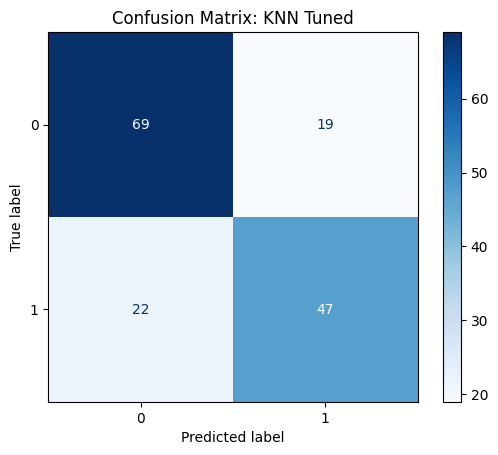

In [6]:
# 1. Модель по умолчанию
knn_default = KNeighborsClassifier()
knn_default.fit(X_train, y_train)
evaluate_model(knn_default, X_test, y_test, "KNN Default")

# 2. Подбор гиперпараметров
params_knn = {
    'n_neighbors': range(3, 20),      # Количество соседей
    'weights': ['uniform', 'distance'], # Веса (равномерные или зависят от расстояния)
    'p': [1, 2] # 1 - Манхэттенское расстояние, 2 - Евклидово
}

knn_grid = GridSearchCV(KNeighborsClassifier(), params_knn, cv=5, scoring='f1')
knn_grid.fit(X_train, y_train)

print("Лучшие параметры KNN:", knn_grid.best_params_)
evaluate_model(knn_grid.best_estimator_, X_test, y_test, "KNN Tuned")

--- Decision Tree Default ---
Accuracy: 0.7197
Precision: 0.7193
Recall: 0.5942
F1-Score: 0.6508
ROC-AUC: 0.7121


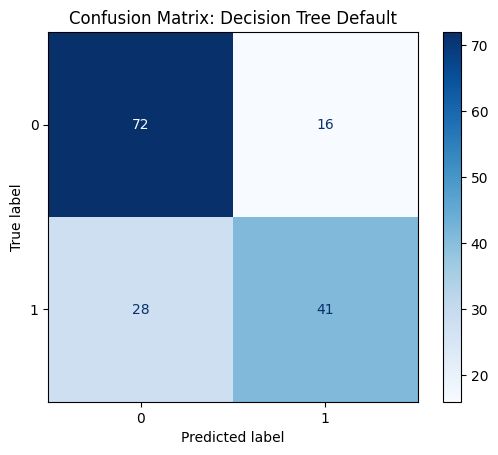



Лучшие параметры Tree: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 10}
--- Decision Tree Tuned ---
Accuracy: 0.7197
Precision: 0.7193
Recall: 0.5942
F1-Score: 0.6508
ROC-AUC: 0.7576


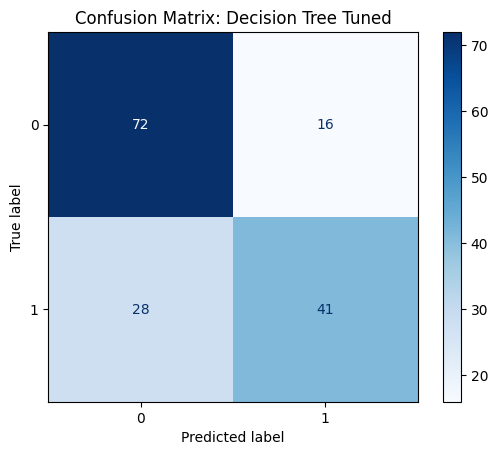

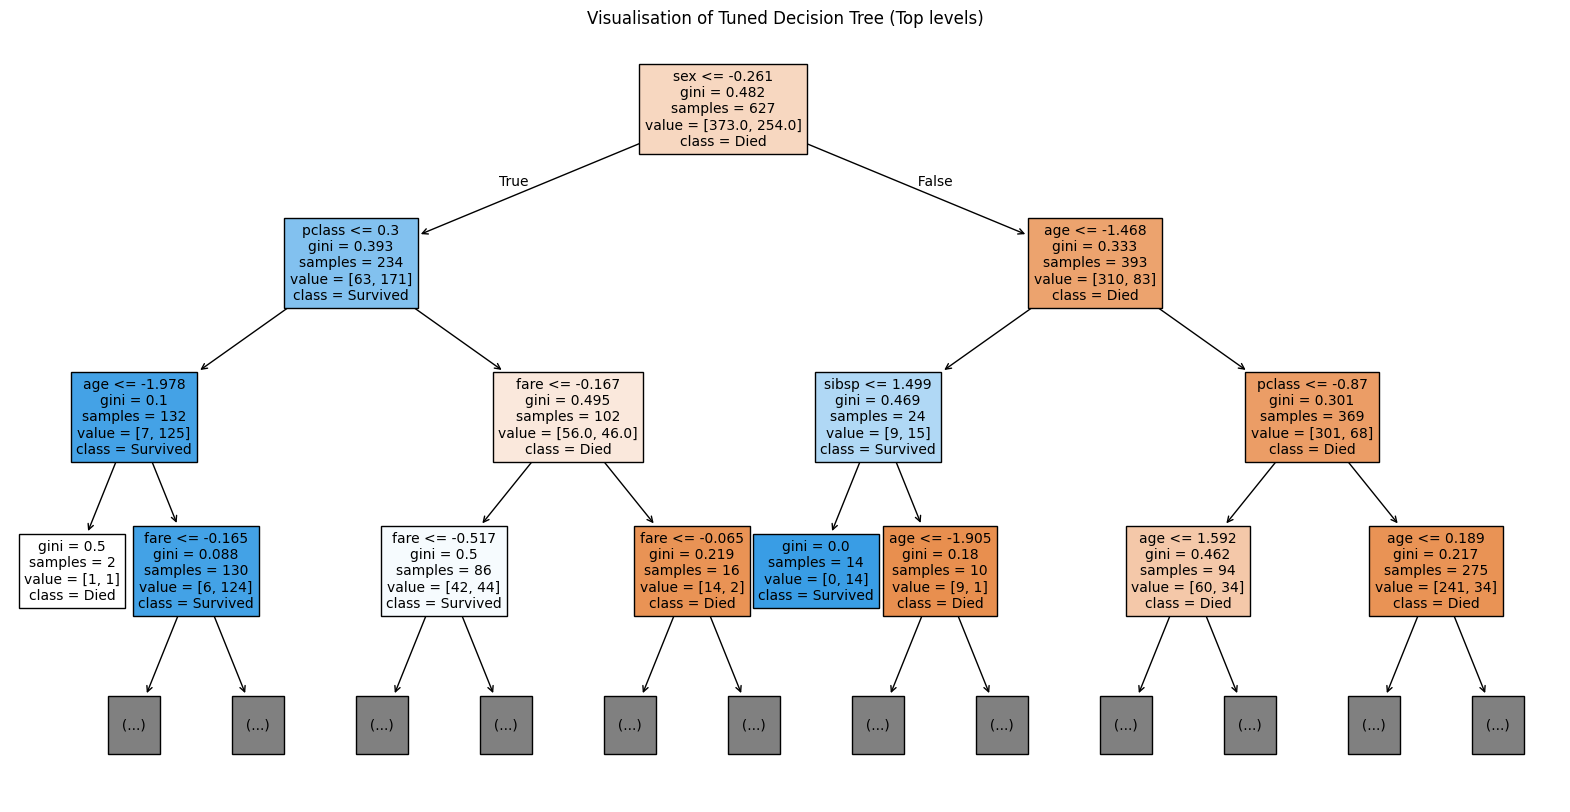

In [7]:
# 1. Модель по умолчанию
tree_default = DecisionTreeClassifier(random_state=42)
tree_default.fit(X_train, y_train)
evaluate_model(tree_default, X_test, y_test, "Decision Tree Default")

# 2. Подбор гиперпараметров
params_tree = {
    'max_depth': [3, 5, 7, 10, None],          # Максимальная глубина дерева
    'min_samples_split': [2, 5, 10],           # Минимум образцов для разделения узла
    'criterion': ['gini', 'entropy']           # Критерий качества разделения
}

tree_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), params_tree, cv=5, scoring='f1')
tree_grid.fit(X_train, y_train)

print("Лучшие параметры Tree:", tree_grid.best_params_)
evaluate_model(tree_grid.best_estimator_, X_test, y_test, "Decision Tree Tuned")

# Визуализация лучшего дерева
plt.figure(figsize=(20,10))
plot_tree(tree_grid.best_estimator_, feature_names=X.columns, class_names=['Died', 'Survived'], filled=True, max_depth=3, fontsize=10)
plt.title("Visualisation of Tuned Decision Tree (Top levels)")
plt.show()

--- Random Forest Default ---
Accuracy: 0.7516
Precision: 0.7500
Recall: 0.6522
F1-Score: 0.6977
ROC-AUC: 0.8081


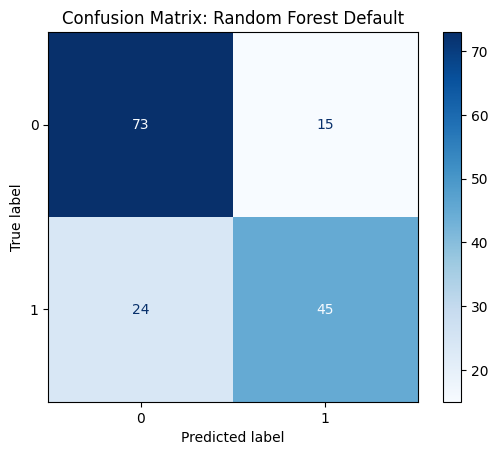



Лучшие параметры RF: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 10}
--- Random Forest Tuned ---
Accuracy: 0.7580
Precision: 0.7719
Recall: 0.6377
F1-Score: 0.6984
ROC-AUC: 0.8407


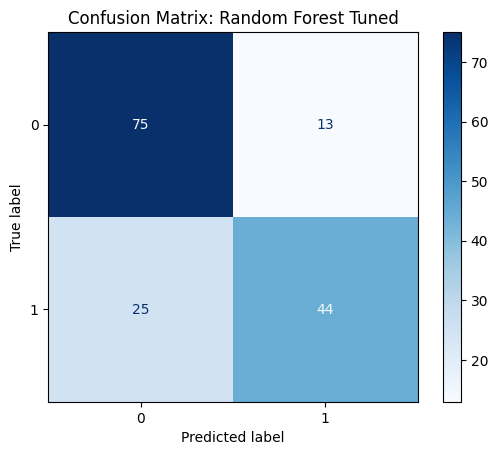

In [8]:
# 1. Модель по умолчанию
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)
evaluate_model(rf_default, X_test, y_test, "Random Forest Default")

# 2. Подбор гиперпараметров (используем RandomizedSearchCV, так как лес учится дольше)
params_rf = {
    'n_estimators': [50, 100, 200],   # Количество деревьев
    'max_depth': [5, 10, None],       # Глубина деревьев
    'min_samples_split': [2, 5, 10]
}

rf_random = RandomizedSearchCV(RandomForestClassifier(random_state=42), params_rf, n_iter=10, cv=3, scoring='f1', random_state=42)
rf_random.fit(X_train, y_train)

print("Лучшие параметры RF:", rf_random.best_params_)
evaluate_model(rf_random.best_estimator_, X_test, y_test, "Random Forest Tuned")